In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/customer_support_tickets.csv")

df.head()


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


In [3]:
df.shape
df.columns
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 61765 entries, 0 to 61764
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   56466 non-null  str    
 1   body      61763 non-null  str    
 2   answer    48576 non-null  str    
 3   type      48587 non-null  str    
 4   queue     61765 non-null  str    
 5   priority  61765 non-null  str    
 6   language  61765 non-null  str    
 7   version   28587 non-null  float64
 8   tag_1     48587 non-null  str    
 9   tag_2     48528 non-null  str    
 10  tag_3     48356 non-null  str    
 11  tag_4     43990 non-null  str    
 12  tag_5     27636 non-null  str    
 13  tag_6     13225 non-null  str    
 14  tag_7     5968 non-null   str    
 15  tag_8     2472 non-null   str    
dtypes: float64(1), str(15)
memory usage: 57.2 MB


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
count,56466,61763,48576,48587,61765,61765,61765,28587.000000,48587,48528,48356,43990,27636,13225,5968,2472
unique,46635,53364,40139,4,52,5,2,NaN,211,350,591,831,956,920,755,512
top,Synchronisationsproblem,Support needed,Currently investigating the issue,Incident,Technical Support,medium,de,NaN,Security,Performance,IT,Tech Support,Tech Support,Tech Support,Tech Support,Documentation
freq,3,2,2,19444,14186,23378,33504,NaN,9156,8698,9430,10004,6904,2606,512,166
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,278.382027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,165.962935,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df["language"].value_counts()

language
de    33504
en    28261
Name: count, dtype: int64

## Decision

Only English tickets will be used in the first version of the project.

Reasons:

- DistilBERT is optimized for English.
- Using one language simplifies preprocessing.
- Approximately 28,000 English tickets are available, which is sufficient for training.
- Multilingual support can be added in future versions using multilingual transformer models.

In [5]:
df = df[df["language"] == "en"].copy()

In [6]:
df.shape

(28261, 16)

In [7]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage.round(2)
})

missing_df

,Missing Values,Percentage (%)
tag_8,26653,94.31
tag_7,24562,86.91
tag_6,20353,72.02
tag_5,11960,42.32
version,11923,42.19
subject,3639,12.88
tag_4,2584,9.14
tag_3,113,0.40
tag_2,16,0.06
answer,6,0.02


## Observations

The missing value analysis indicates that the dataset is largely complete for the features required in this project.

Several tag columns (`tag_5` to `tag_8`) contain a high percentage of missing values. Since these columns are not part of the initial modeling objective, they will be excluded from preprocessing and model training.

The `version` column also contains approximately 42% missing values. As product version is not required for ticket classification, this column will not be used in the first version of the project.

The `subject` column contains approximately 13% missing values. Rather than removing these records, missing subjects will be replaced with an empty string. This preserves valuable training examples while allowing the model to rely on the ticket body when the subject is unavailable.

The `body` column is nearly complete, with only one missing value. Since the body contains the primary textual information for classification, the single incomplete record will be removed.

The target columns (`priority`, `queue`, and `type`) contain no missing values, making them suitable for supervised learning without additional preprocessing.

In [8]:
# Duplicate Analysis

#Duplicate records can negatively impact model evaluation by causing data leakage between the training and test sets.

#In this section, we identify duplicate rows as well as duplicate tickets based on the textual content (`subject` and `body`). If duplicate tickets exist, we will decide whether they should be removed before training.

df.duplicated().sum()

df.duplicated(subset=["subject", "body"]).sum()

np.int64(4513)

In [9]:
print(f"Rows before removing duplicates: {len(df)}")

Rows before removing duplicates: 28261


In [10]:
df = df.drop_duplicates()

In [11]:
print(f"Rows after removing duplicates: {len(df)}")

Rows after removing duplicates: 28261


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
print("Exact duplicate rows:", df.duplicated().sum())

print(
    "Duplicate subject/body:",
    df.duplicated(subset=["subject", "body"]).sum()
)

Exact duplicate rows: 0
Duplicate subject/body: 4513


In [14]:
before = len(df)

df_no_duplicates = df.drop_duplicates()

after = len(df_no_duplicates)

print(f"Before: {before}")
print(f"After : {after}")
print(f"Removed: {before - after}")

Before: 28261
After : 28261
Removed: 0


In [15]:
duplicate_tickets = df[
    df.duplicated(subset=["subject", "body"], keep=False)
]

duplicate_tickets.head(10)

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
9992,Problem with Cross-User Data Synchronization,Users are facing difficulties in syncing proje...,Received an email about the issue with cross-u...,Incident,Product Support,low,en,400.0,Bug,Network,Performance,IT,Tech Support,NaN,NaN,NaN
9994,Enhance User Interface,The current UI is cumbersome. Please improve n...,Forwarding your feedback to the development te...,Change,Product Support,medium,en,400.0,Feature,Feedback,Documentation,NaN,NaN,NaN,NaN,NaN
10013,Report on Connectivity Problem,"To Customer Support, I am submitting a report ...","<name>, thank you for reporting the connectivi...",Incident,Customer Service,medium,en,400.0,Network,Performance,Outage,Disruption,IT,Tech Support,NaN,NaN
10015,Optimization of Investments Through Data Analy...,"Hello, inquiring about the data analytics serv...",Thank you for reaching out to our customer sup...,Request,Customer Service,medium,en,400.0,Feature,Performance,Documentation,Feedback,IT,Tech Support,NaN,NaN
10018,NaN,"Customer Support, inquiring about digital stra...","<name>, thanks for your interest in our digita...",Request,Technical Support,high,en,400.0,Feedback,Sales,Tech Support,NaN,NaN,NaN,NaN,NaN
10019,Requirements for Secure Data Protection Services,Could you please share details about secure da...,<name> offers secure data protection services ...,Request,Service Outages and Maintenance,high,en,400.0,Security,Documentation,IT,Tech Support,NaN,NaN,NaN,NaN
10025,Microsoft SQL Support,Seeking guidance on integrating project manage...,"Will provide API guides, setup tutorials, and ...",Request,Customer Service,medium,en,400.0,Documentation,IT,Tech Support,Performance,NaN,NaN,NaN,NaN
10033,Issue with Billing for Analytical Services,"Hello, I am writing to address the discrepanci...","Dear [Customer Name], we acknowledge your emai...",Problem,Billing and Payments,medium,en,400.0,Billing,Payment,Refund,Disruption,NaN,NaN,NaN,NaN
10036,Assistance Required for Integrating Asana with...,I need guidance on how to integrate Asana with...,Please provide the integration steps and requi...,Request,Product Support,medium,en,400.0,Feature,Documentation,IT,Tech Support,NaN,NaN,NaN,NaN
10038,Concern Regarding Security of Hospital System,A data breach has been identified in the hospi...,We are in contact regarding the security conce...,Incident,IT Support,medium,en,400.0,Security,Bug,IT,Tech Support,NaN,NaN,NaN,NaN


In [16]:
duplicate_tickets.groupby(["subject", "body"]).size().sort_values(ascending=False).head(10)

subject                                                                                                body                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
 Reported Problem with Data Access                                                                     Faced data access problems after the software update, which might be related to Scikit-learn and Oracle Database incompatibility.                                                            

In [17]:
duplicate_tickets[
    ["subject", "body", "priority", "queue", "type"]
].sort_values(["subject", "body"]).head(20)

,subject,body,priority,queue,type
18651,Reported Problem with Data Access,Faced data access problems after the software ...,medium,Product Support,Problem
59471,Reported Problem with Data Access,Faced data access problems after the software ...,medium,Product Support,Problem
16189,Urgent Support Required for Project Managemen...,Our project management platform is currently f...,high,Technical Support,Incident
60388,Urgent Support Required for Project Managemen...,Our project management platform is currently f...,high,Technical Support,Incident
18423,API Integration Support Request,I am interested in learning about the API inte...,high,Technical Support,Request
51226,API Integration Support Request,I am interested in learning about the API inte...,high,Technical Support,Request
15272,AR Brille Oracle Support,Is it possible to provide comprehensive docume...,high,Technical Support,Request
43314,AR Brille Oracle Support,Is it possible to provide comprehensive docume...,high,Technical Support,Request
27730,Ableton Live 11 Suite Integrations,Seeking to understand the integrations availab...,low,Technical Support,Request
59840,Ableton Live 11 Suite Integrations,Seeking to understand the integrations availab...,low,Technical Support,Request


In [18]:
first_group = (
    duplicate_tickets[["subject", "body"]]
    .drop_duplicates()
    .iloc[0]
)

first_group

subject         Problem with Cross-User Data Synchronization
body       Users are facing difficulties in syncing proje...
Name: 9992, dtype: str

In [19]:
subject = first_group["subject"]
body = first_group["body"]

duplicate_tickets[
    (duplicate_tickets["subject"] == subject) &
    (duplicate_tickets["body"] == body)
]

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
9992,Problem with Cross-User Data Synchronization,Users are facing difficulties in syncing proje...,Received an email about the issue with cross-u...,Incident,Product Support,low,en,400.0,Bug,Network,Performance,IT,Tech Support,NaN,NaN,NaN
46453,Problem with Cross-User Data Synchronization,Users are facing difficulties in syncing proje...,Received an email concerning the issue with cr...,Incident,Product Support,low,en,NaN,Bug,Network,Performance,IT,Tech Support,NaN,NaN,NaN


## Duplicate Analysis

The initial analysis found no exact duplicate rows in the English subset of the dataset. However, **4,513 records shared identical `subject` and `body` values**.

A detailed investigation showed that these records differed only in metadata fields such as the support agent's response (`answer`) and the product `version`, while the modeling columns (`subject`, `body`, `priority`, `queue`, and `type`) remained identical.

Since the objective of this project is to predict ticket metadata from the customer ticket text, duplicate removal will be performed using only the columns relevant to the machine learning task. This ensures that repeated training examples do not bias the model while preserving genuinely distinct tickets.

In [20]:
model_columns = [
    "subject",
    "body",
    "priority",
    "queue",
    "type"
]

df = df.drop_duplicates(subset=model_columns)

# 7. Text Analysis

The performance of any Natural Language Processing (NLP) model depends heavily on the characteristics of the input text.

In this section, we analyze the textual features of the customer support tickets.

The objectives are:

- Measure the length of ticket subjects.
- Measure the length of ticket bodies.
- Identify unusually short or long tickets.
- Understand how ticket length may influence model selection and preprocessing.

These insights will help determine whether the text needs cleaning, truncation, or additional preprocessing before training the machine learning models.

In [21]:
df["subject_length"] = df["subject"].fillna("").str.len()

df["body_length"] = df["body"].fillna("").str.len()

In [22]:
df["subject_length"].describe()

count    23748.000000
mean        38.225914
std         20.359744
min          0.000000
25%         29.000000
50%         39.000000
75%         50.000000
max        258.000000
Name: subject_length, dtype: float64

In [23]:
df["body_length"].describe()

count    23748.000000
mean       376.388201
std        207.302821
min          0.000000
25%        205.000000
50%        372.000000
75%        537.000000
max       1793.000000
Name: body_length, dtype: float64

In [24]:
df["subject_word_count"] = (
    df["subject"]
    .fillna("")
    .str.split()
    .str.len()
)

df["body_word_count"] = (
    df["body"]
    .fillna("")
    .str.split()
    .str.len()
)

In [25]:
df["subject_word_count"].describe()

count    23748.000000
mean         5.032971
std          2.732877
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         37.000000
Name: subject_word_count, dtype: float64

In [26]:
df["body_word_count"].describe()

count    23748.000000
mean        56.142244
std         31.939809
min          0.000000
25%         30.000000
50%         55.000000
75%         79.000000
max        272.000000
Name: body_word_count, dtype: float64

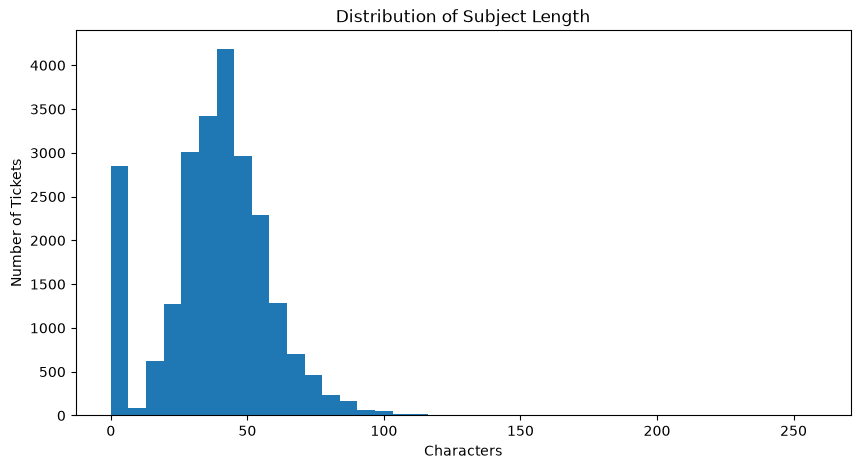

In [27]:
plt.figure(figsize=(10,5))

plt.hist(df["subject_length"], bins=40)

plt.title("Distribution of Subject Length")

plt.xlabel("Characters")

plt.ylabel("Number of Tickets")

plt.show()

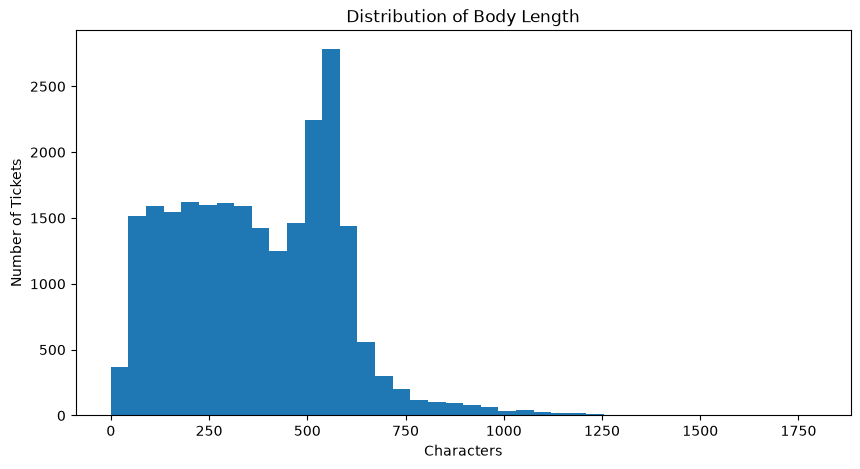

In [28]:
plt.figure(figsize=(10,5))

plt.hist(df["body_length"], bins=40)

plt.title("Distribution of Body Length")

plt.xlabel("Characters")

plt.ylabel("Number of Tickets")

plt.show()

In [29]:
df.nlargest(
    5,
    "body_length"
)[
    [
        "subject",
        "body",
        "body_length",
        "body_word_count"
    ]
]

,subject,body,body_length,body_word_count
58369,Problem with Inaccurate Invoice,"Dear Customer Support,\n\nI am writing to expr...",1793,272
46318,Refresh Digital Marketing Strategy for Enhance...,"Dear Customer Support,\n\nI am contacting you ...",1748,239
48281,NaN,"Dear Customer Support, <br><br>I am contacting...",1702,257
42297,Support for Integrating Firebase on macOS,"Hello [Your Name],\n\nI hope this message find...",1672,251
49678,NaN,"Hello Customer Support,\n\nI hope this message...",1606,253


In [30]:
df.nsmallest(
    5,
    "body_length"
)[
    [
        "subject",
        "body",
        "body_length",
        "body_word_count"
    ]
]

,subject,body,body_length,body_word_count
59452,Moodle integration broke unexpectedly due to a...,NaN,0,0
42314,NaN,Help,4,1
7607,Experiencing Downtime on Multiple Platforms,System,6,1
1103,Facing System Downtime on Multiple Platforms,Our system,10,2
54460,Concerns Regarding Hospital Data Security,Seeking Help,12,2


## Observations

The textual characteristics of the dataset were analyzed using both character counts and word counts.

### Subject

- The average subject length is **38 characters** (approximately **5 words**).
- The distribution is relatively symmetric, indicating consistent subject lengths.
- A small number of subjects have zero length due to missing values that were temporarily replaced with empty strings for analysis.

### Body

- The average body length is **376 characters** (approximately **56 words**).
- Most ticket bodies fall between **200 and 600 characters**, indicating that customer support requests are generally concise.
- The distribution exhibits a slight right skew caused by a small number of unusually long tickets.
- The longest ticket contains **1,793 characters (272 words)**, which is still within a reasonable range for transformer-based models after tokenization.

### Engineering Decisions

Based on the analysis:

- Missing subjects will not be removed because the ticket body contains sufficient information for classification.
- Rows with empty ticket bodies will be removed during preprocessing because they do not provide meaningful textual information.
- Subject and body text will later be combined into a single input sequence before training.
- The observed ticket lengths indicate that DistilBERT should be able to process the vast majority of tickets without significant truncation.

## 8. Target Label Distribution Analysis

Before training the classification models, the distributions of the available target labels were examined.

The dataset contains three important classification labels:

- `type` — describes the nature of the support ticket.
- `queue` — identifies the support team or department associated with the ticket.
- `priority` — indicates the urgency of the ticket.

### Class Distribution

The frequency and percentage distribution of each label were analyzed to identify potential class imbalance.

Class imbalance is important because a model trained on highly imbalanced data may favor the majority class and achieve misleadingly high accuracy while performing poorly on minority classes.



In [31]:
print("Queue:")
print(df["queue"].value_counts())

print("\nType:")
print(df["type"].value_counts())

print("\nPriority:")
print(df["priority"].value_counts())

Queue:
queue
Technical Support                  6858
Product Support                    4430
Customer Service                   3570
IT Support                         2833
Billing and Payments               2420
Returns and Exchanges              1173
Service Outages and Maintenance     937
Sales and Pre-Sales                 724
Human Resources                     461
General Inquiry                     342
Name: count, dtype: int64

Type:
type
Incident    9433
Request     6880
Problem     4932
Change      2503
Name: count, dtype: int64

Priority:
priority
medium    9754
high      9149
low       4845
Name: count, dtype: int64


In [32]:
print("Queue:")
print(df["queue"].value_counts(normalize=True).mul(100).round(2))

print("\nType:")
print(df["type"].value_counts(normalize=True).mul(100).round(2))

print("\nPriority:")
print(df["priority"].value_counts(normalize=True).mul(100).round(2))

Queue:
queue
Technical Support                  28.88
Product Support                    18.65
Customer Service                   15.03
IT Support                         11.93
Billing and Payments               10.19
Returns and Exchanges               4.94
Service Outages and Maintenance     3.95
Sales and Pre-Sales                 3.05
Human Resources                     1.94
General Inquiry                     1.44
Name: proportion, dtype: float64

Type:
type
Incident    39.72
Request     28.97
Problem     20.77
Change      10.54
Name: proportion, dtype: float64

Priority:
priority
medium    41.07
high      38.53
low       20.40
Name: proportion, dtype: float64


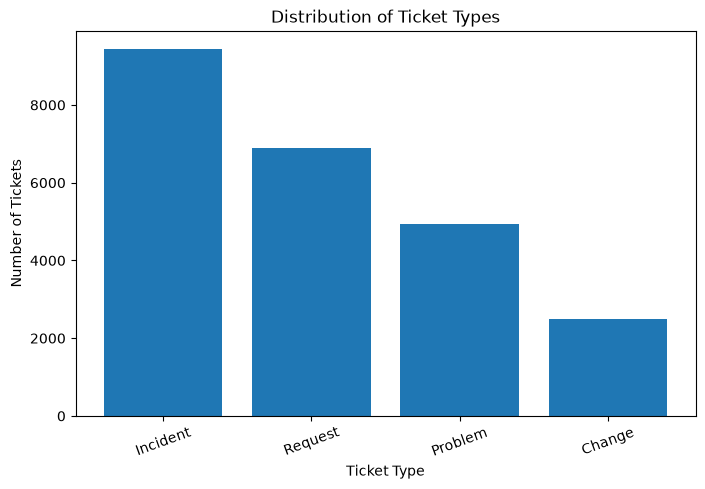

In [33]:
type_counts = df["type"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(type_counts.index, type_counts.values)

plt.title("Distribution of Ticket Types")
plt.xlabel("Ticket Type")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=20)

plt.show()

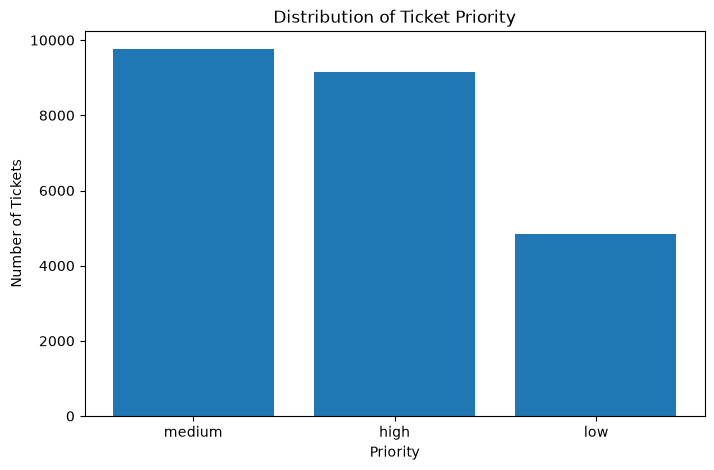

In [34]:
priority_counts = df["priority"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(priority_counts.index, priority_counts.values)

plt.title("Distribution of Ticket Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")

plt.show()

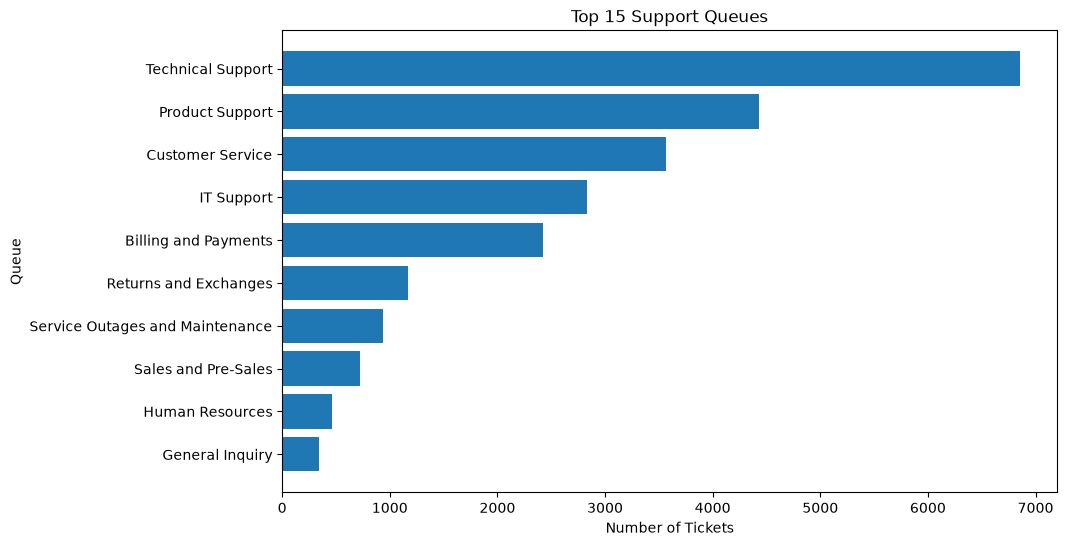

In [35]:
queue_counts = df["queue"].value_counts().head(15)

plt.figure(figsize=(10, 6))

plt.barh(queue_counts.index[::-1], queue_counts.values[::-1])

plt.title("Top 15 Support Queues")
plt.xlabel("Number of Tickets")
plt.ylabel("Queue")

plt.show()

In [36]:
for column in ["type", "priority", "queue"]:
    counts = df[column].value_counts()

    print(f"\n{column}")
    print("Largest class:", counts.max())
    print("Smallest class:", counts.min())
    print("Imbalance ratio:", round(counts.max() / counts.min(), 2))


type
Largest class: 9433
Smallest class: 2503
Imbalance ratio: 3.77

priority
Largest class: 9754
Smallest class: 4845
Imbalance ratio: 2.01

queue
Largest class: 6858
Smallest class: 342
Imbalance ratio: 20.05


In [37]:
pd.crosstab(
    df["type"],
    df["priority"]
)

priority,high,low,medium
type,,,
Change,981,503,1019
Incident,4045,1750,3638
Problem,1822,1032,2078
Request,2301,1560,3019


In [38]:
pd.crosstab(
    df["type"],
    df["priority"],
    normalize="index"
).mul(100).round(2)

priority,high,low,medium
type,,,
Change,39.19,20.10,40.71
Incident,42.88,18.55,38.57
Problem,36.94,20.92,42.13
Request,33.44,22.67,43.88


## 8. Target Label Distribution Analysis

The distributions of the three primary classification labels — `type`, `priority`, and `queue` — were analyzed to identify class imbalance and understand the difficulty of the classification tasks.

### Ticket Type

The dataset contains four ticket types:

- Incident: 9,433 tickets (39.72%)
- Request: 6,880 tickets (28.97%)
- Problem: 4,932 tickets (20.77%)
- Change: 2,503 tickets (10.54%)

Incident is the most frequent ticket type, while Change is the least frequent. The largest-to-smallest class ratio is approximately 3.77.

This represents moderate class imbalance. However, the minority class still contains 2,503 examples, so there is no immediate need to remove or artificially oversample classes during EDA.

### Priority

The priority distribution consists of:

- Medium: 9,754 tickets (41.07%)
- High: 9,149 tickets (38.53%)
- Low: 4,845 tickets (20.40%)

The largest-to-smallest class ratio is approximately 2.01. Medium and High priority tickets are considerably more common than Low priority tickets, but the imbalance is manageable.

Because minority-class performance may still be affected, model evaluation will include precision, recall, and F1-score for each priority class rather than relying only on overall accuracy.

### Queue

The support queue distribution is considerably more imbalanced than the other labels.

Among the top queues, Technical Support is the most frequent category with 6,858 tickets (28.88%), while General Inquiry has 342 tickets (1.44%).

The displayed top-10 queues have a largest-to-smallest ratio of approximately 20.05. This indicates that routing-team classification is likely to be a more challenging classification task than ticket type or priority classification.

The complete queue distribution will be examined before finalizing the modeling strategy.

### Relationship Between Type and Priority

A cross-tabulation was used to examine the relationship between ticket type and priority.

The results show that ticket type and priority are related but not deterministically linked. For example, Incident tickets have a relatively high proportion of High priority labels (42.88%), while Request tickets have a larger proportion of Medium priority labels (43.88%).

However, each ticket type contains multiple priority levels. Therefore, the text content remains important for predicting priority, rather than simply using ticket type as a proxy.

### Modeling Implications

The analysis indicates that the three classification tasks have different levels of class imbalance.

Ticket type and priority have moderate imbalance, while queue/routing has substantially greater imbalance.

For this reason, the evaluation stage will use class-level precision, recall, and F1-score in addition to accuracy. Confusion matrices will also be used to identify which classes the models systematically confuse.

In [39]:
pd.crosstab(
    df["queue"],
    df["type"]
)

type,Change,Incident,Problem,Request
queue,,,,
Billing and Payments,137,575,520,1188
Customer Service,293,916,733,1628
General Inquiry,88,111,61,82
Human Resources,33,231,53,144
IT Support,496,998,740,599
Product Support,507,1945,983,995
Returns and Exchanges,156,450,229,338
Sales and Pre-Sales,133,141,98,352
Service Outages and Maintenance,222,517,57,141


In [40]:
pd.crosstab(
    df["queue"],
    df["type"],
    normalize="index"
).mul(100).round(2)

type,Change,Incident,Problem,Request
queue,,,,
Billing and Payments,5.66,23.76,21.49,49.09
Customer Service,8.21,25.66,20.53,45.60
General Inquiry,25.73,32.46,17.84,23.98
Human Resources,7.16,50.11,11.50,31.24
IT Support,17.51,35.23,26.12,21.14
Product Support,11.44,43.91,22.19,22.46
Returns and Exchanges,13.30,38.36,19.52,28.82
Sales and Pre-Sales,18.37,19.48,13.54,48.62
Service Outages and Maintenance,23.69,55.18,6.08,15.05


In [41]:
pd.crosstab(
    df["queue"],
    df["priority"],
    normalize="index"
).mul(100).round(2)

priority,high,low,medium
queue,,,
Billing and Payments,29.50,21.28,49.21
Customer Service,18.66,32.75,48.60
General Inquiry,15.79,59.06,25.15
Human Resources,10.63,47.72,41.65
IT Support,47.09,9.81,43.10
Product Support,29.75,19.07,51.17
Returns and Exchanges,21.48,38.02,40.49
Sales and Pre-Sales,17.40,35.64,46.96
Service Outages and Maintenance,70.54,12.38,17.08


##Label consistency analysis

In [42]:
df.groupby(
    ["queue", "type", "priority"]
).size().sort_values(ascending=False).head(20)

queue                            type      priority
Technical Support                Incident  high        2084
                                           medium      1061
Product Support                  Incident  medium       952
Technical Support                Problem   high         833
                                 Request   high         806
Customer Service                 Request   medium       775
Product Support                  Incident  high         609
Billing and Payments             Request   medium       595
Product Support                  Request   medium       535
Customer Service                 Request   low          524
Product Support                  Problem   medium       516
IT Support                       Incident  high         488
Technical Support                Request   medium       466
Customer Service                 Incident  medium       433
IT Support                       Incident  medium       431
Technical Support                Problem   mediu

In [43]:
combination_counts = (
    df.groupby(["queue", "type", "priority"])
      .size()
      .sort_values()
)

combination_counts.head(20)

queue                            type      priority
Human Resources                  Change    high         1
                                 Problem   high         3
General Inquiry                  Request   high         5
                                 Change    high         7
Service Outages and Maintenance  Problem   medium       8
Human Resources                  Change    low         12
General Inquiry                  Problem   high        12
Service Outages and Maintenance  Problem   low         13
                                 Request   low         14
General Inquiry                  Incident  medium      15
                                 Problem   medium      15
Sales and Pre-Sales              Incident  high        16
                                 Problem   high        17
Human Resources                  Request   high        18
                                 Problem   medium      19
                                 Change    medium      20
Service Outages and 

In [44]:
rare_combination = combination_counts.index[0]

rare_tickets = df[
    (df["queue"] == rare_combination[0]) &
    (df["type"] == rare_combination[1]) &
    (df["priority"] == rare_combination[2])
]

rare_tickets[
    ["subject", "body", "queue", "type", "priority"]
].head(10)

,subject,body,queue,type,priority
61168,Enhance Brand Expansion Tactics,"Dear Customer Assistance, I am contacting you ...",Human Resources,Change,high


## 9. Label Quality and Rare Combinations

After examining the overall label distributions, the combinations of `queue`, `type`, and `priority` were analyzed to identify potentially unusual or rare label combinations.

The most frequent combinations were generally consistent with the expected support-ticket structure. For example, Technical Support tickets frequently appeared as Incidents with High or Medium priority.

Several combinations occurred very infrequently. For example, the combination of Human Resources, Change, and High priority occurred only once in the filtered dataset.

Rare combinations were not automatically removed because a low-frequency combination does not necessarily indicate an incorrect label. Some legitimate business cases may naturally occur only a few times.

Instead, representative examples from rare combinations were inspected manually to determine whether the ticket text was consistent with its assigned queue, type, and priority.

This analysis is important because classification models learn directly from the provided labels. Incorrect or inconsistent labels can introduce label noise and negatively affect model performance.

At this stage, no records were removed solely because their label combination was rare. Records will only be removed during preprocessing when there is clear evidence of unusable text, missing target labels, duplication, or other data-quality problems.

### English-Only Dataset

The original dataset contains both English and German tickets. Since the project scope is focused on English-language support-ticket classification, the analysis and subsequent modeling will use the English subset.

After filtering for English tickets, the working dataset contains 23,748 records.

# 10. Exploratory Data Analysis — Summary and Findings

Exploratory Data Analysis (EDA) was performed to understand the structure, quality, text characteristics, and label distributions of the customer support ticket dataset before applying machine learning models.

The purpose of this analysis was not only to visualize the data, but also to identify potential data-quality issues and understand how the characteristics of the dataset would affect the subsequent modeling process.

---

## 10.1 Dataset Overview

The original dataset contains 61,765 support ticket records and 16 columns.

The main fields relevant to the classification task are:

- `subject` — subject/title of the support ticket
- `body` — detailed description of the customer's issue
- `type` — type of ticket
- `queue` — support team/department responsible for the ticket
- `priority` — priority assigned to the ticket
- `language` — language of the ticket
- `answer` — support response
- `version` — product/system version
- `tag_1` through `tag_8` — additional ticket tags

Since this project focuses on English-language support-ticket classification, German-language records were excluded from the modeling dataset.

After filtering for English tickets, the working dataset contains 23,748 records.

The primary input for the classification models will be the textual content of the ticket, particularly the combination of `subject` and `body`.

## 10.2 Data Types and Structure

The dataset contains primarily textual/categorical fields, with `version` represented as a numerical field.

The text fields contain customer-generated or support-related language, while the categorical fields describe how each ticket was classified by the support organization.

The dataset therefore represents a supervised text classification problem, where historical support tickets and their assigned labels can be used to train models for automatically classifying new tickets.

## 10.3 Missing Value Analysis

Missing values were analyzed across all columns.

The largest amount of missing data was found in the optional tag fields and the `version` field.

The following fields had notable missing values in the original dataset:

- `tag_8` — approximately 94.31% missing
- `tag_7` — approximately 86.91% missing
- `tag_6` — approximately 72.02% missing
- `tag_5` — approximately 42.32% missing
- `version` — approximately 42.19% missing
- `subject` — approximately 12.88% missing
- `tag_4` — approximately 9.14% missing

The remaining fields had very few or no missing values.

The high proportion of missing values in the optional tag fields suggests that these fields are not consistently populated and may not be reliable primary features for the classification task.

Since the project is primarily focused on understanding and classifying the natural-language content of support tickets, the `subject` and `body` fields will be treated as the primary input features.

Missing textual values will be handled carefully during preprocessing rather than allowing missing values to enter the text vectorization or transformer pipeline directly.

Target labels such as `type`, `priority`, and `queue` will be checked for missing values before model training because records without target labels cannot be used as supervised training examples.

## 10.4 Duplicate Analysis

Duplicate records were investigated at two levels:

1. Exact duplicate rows across all columns.
2. Duplicate tickets based specifically on `subject` and `body`.

No exact duplicate rows were found after loading the English working dataset.

However, 4,513 records contained duplicate combinations of `subject` and `body`.

This distinction is important.

An identical subject and body does not necessarily mean that two records are invalid duplicates. The records may have different metadata such as queue, priority, type, tags, or version.

Therefore, duplicate subject/body records were not automatically removed during EDA.

Instead, they were investigated to determine whether they represented repeated support-ticket templates or potential label inconsistencies.

This is particularly important for machine learning because repeated or near-identical tickets can potentially cause data leakage if similar examples appear in both the training and test sets.

The treatment of these records will therefore be considered carefully during dataset splitting and preprocessing.

## 10.5 Language Analysis

The dataset contains two languages:

- English (`en`)
- German (`de`)

The project scope is limited to English-language support tickets.

Therefore, German records were excluded before continuing with the modeling pipeline.

This reduces language variability and ensures that the baseline TF-IDF model and the fine-tuned transformer are evaluated on a consistent language domain.

The resulting English-only working dataset contains 23,748 records.

## 10.6 Text Length Analysis

The length of the `subject` and `body` fields was analyzed using both character counts and word counts.

Additional features were temporarily created for EDA:

- `subject_length`
- `body_length`
- `subject_word_count`
- `body_word_count`

These features were used only to understand the dataset and are not themselves intended to be the primary model inputs.

### Subject Length

The subject length statistics were:

- Mean: approximately 38.23 characters
- Median: 39 characters
- Standard deviation: approximately 20.36 characters
- Minimum: 0 characters
- Maximum: 258 characters

The mean and median are very close, indicating that the typical subject length is relatively stable.

The presence of zero-length subjects is consistent with the missing-value analysis and indicates that some records do not contain a subject.

### Body Length

The body length statistics were:

- Mean: approximately 376.39 characters
- Median: 372 characters
- Standard deviation: approximately 207.30 characters
- Minimum: 0 characters
- Maximum: 1,793 characters

The mean and median are again relatively close, suggesting that the majority of ticket bodies are centered around a similar range of lengths, although some substantially longer tickets are present.

### Subject Word Count

The subject contained:

- Mean: approximately 5.03 words
- Median: 5 words
- Minimum: 0 words
- Maximum: 37 words

### Body Word Count

The body contained:

- Mean: approximately 56.14 words
- Median: 55 words
- Minimum: 0 words
- Maximum: 272 words

Overall, the text is relatively short compared with long-form documents, which is suitable for transformer-based text classification.

The length distributions will also help inform the maximum sequence length used during transformer preprocessing.

## 10.7 Target Label Distribution

The dataset contains three major classification labels relevant to the support-ticket triage problem:

- `type` — ticket category/type
- `priority` — ticket urgency
- `queue` — support routing team

The distributions of these labels were examined before modeling.

### Ticket Type

| Type | Count | Percentage |
|---|---:|---:|
| Incident | 9,433 | 39.72% |
| Request | 6,880 | 28.97% |
| Problem | 4,932 | 20.77% |
| Change | 2,503 | 10.54% |

Incident is the most common ticket type, while Change is the least common.

The largest-to-smallest class ratio is approximately 3.77.

This represents moderate class imbalance, but the smallest class still contains 2,503 examples. Therefore, there is no immediate need to remove or artificially duplicate classes.

## 10.8 Priority Distribution

The priority labels are distributed as follows:

| Priority | Count | Percentage |
|---|---:|---:|
| Medium | 9,754 | 41.07% |
| High | 9,149 | 38.53% |
| Low | 4,845 | 20.40% |

Medium and High priority tickets make up the majority of the dataset.

The largest-to-smallest class ratio is approximately 2.01, indicating relatively moderate class imbalance.

Because the Low priority class is less frequent, model evaluation should not rely solely on accuracy. Per-class precision, recall, and F1-score will be used to determine whether the model performs adequately across all priority levels.

## 10.9 Queue Distribution

The support queue distribution is considerably more imbalanced than the ticket type and priority distributions.

The most frequent queues in the English working dataset include:

| Queue | Count | Percentage |
|---|---:|---:|
| Technical Support | 6,858 | 28.88% |
| Product Support | 4,430 | 18.65% |
| Customer Service | 3,570 | 15.03% |
| IT Support | 2,833 | 11.93% |
| Billing and Payments | 2,420 | 10.19% |
| Returns and Exchanges | 1,173 | 4.94% |
| Service Outages and Maintenance | 937 | 3.95% |
| Sales and Pre-Sales | 724 | 3.05% |
| Human Resources | 461 | 1.94% |
| General Inquiry | 342 | 1.44% |

Technical Support is the largest queue, while General Inquiry is one of the least frequent among the displayed queues.

The largest-to-smallest ratio for these displayed queues is approximately 20.05.

This indicates substantial class imbalance in the routing-team classification problem.

Because of this imbalance, accuracy alone would not provide a complete picture of model performance. Per-class evaluation and confusion matrices will be particularly important for queue classification.

## 10.10 Relationships Between Target Labels

Cross-tabulations were used to investigate relationships between `type`, `priority`, and `queue`.

### Type × Priority

The relationship between ticket type and priority showed several patterns.

For example:

- 42.88% of Incident tickets were High priority.
- 38.57% of Incident tickets were Medium priority.
- 43.88% of Request tickets were Medium priority.
- 33.44% of Request tickets were High priority.

This indicates that ticket type and priority are related, but they are not deterministically linked.

For example, an Incident can still be Low or Medium priority, while a Request can still be High priority.

Therefore, ticket text contains information that is not completely represented by the other labels.

### Queue × Type

The relationship between queue and ticket type showed strong patterns for certain support teams.

For example:

- Technical Support tickets were 51.75% Incident.
- Service Outages and Maintenance tickets were 55.18% Incident.
- Billing and Payments tickets were 49.09% Request.
- Sales and Pre-Sales tickets were 48.62% Request.

These patterns are consistent with the expected business meaning of the support queues.

However, no queue was completely determined by a single ticket type. Each queue contained multiple ticket types.

### Queue × Priority

The relationship between queue and priority also showed meaningful patterns.

For example:

- Service Outages and Maintenance was 70.54% High priority.
- Technical Support was 57.96% High priority.
- General Inquiry was 59.06% Low priority.
- Human Resources was 47.72% Low priority and 41.65% Medium priority.

This suggests that the support queue and priority labels contain meaningful business relationships.

However, these relationships are not deterministic and should not replace analysis of the actual ticket text.

## 10.11 Rare Label Combinations

The combinations of `queue`, `type`, and `priority` were analyzed to identify potentially unusual records.

Several combinations occurred only a small number of times. For example:

- Human Resources + Change + High — 1 record
- General Inquiry + Request + High — 5 records
- General Inquiry + Change + High — 7 records
- Service Outages and Maintenance + Problem + Medium — 8 records

Rare combinations were not automatically removed.

A rare combination does not necessarily indicate an incorrect label. Real-world support systems can contain legitimate edge cases that occur infrequently.

Representative examples were inspected manually to determine whether the text was consistent with the assigned labels.

This analysis highlighted the possibility of label noise, but there was not sufficient evidence to remove records solely because their label combination was rare.

Therefore, rare combinations were retained unless another clear data-quality problem was identified.

# 11. Overall EDA Findings

The exploratory analysis provided several important insights into the dataset and helped define the modeling strategy.

### Finding 1 — The dataset is suitable for supervised text classification

The dataset contains thousands of English-language support tickets with associated labels describing ticket type, priority, and support queue.

This provides sufficient labeled data for training and evaluating text classification models.

### Finding 2 — Ticket text is relatively short

The median subject length is approximately 39 characters and the median body length is approximately 372 characters.

The median body contains approximately 55 words.

This makes the dataset suitable for both traditional NLP approaches such as TF-IDF and transformer-based models such as DistilBERT.

### Finding 3 — Missing values are concentrated in optional fields

Several tag fields and the version field contain substantial amounts of missing data.

Because these fields are inconsistently populated, the initial modeling pipeline will focus primarily on the natural-language content of the ticket rather than relying heavily on optional metadata.

### Finding 4 — Duplicate subject/body combinations exist

No exact duplicate rows were found after filtering, but 4,513 records contained duplicate subject/body combinations.

These records were not automatically removed because their associated metadata may differ.

Repeated text will be considered when creating train/validation/test splits to reduce the possibility of information leakage between datasets.

### Finding 5 — Ticket type has moderate class imbalance

Incident represents 39.72% of the data, while Change represents 10.54%.

The imbalance ratio is approximately 3.77.

The minority class still contains enough examples for training, so the classes will initially be retained.

### Finding 6 — Priority has relatively mild class imbalance

Medium and High priority tickets represent 41.07% and 38.53% respectively, while Low priority represents 20.40%.

The imbalance ratio is approximately 2.01.

Class-level evaluation will therefore be important, particularly for the Low priority class.

### Finding 7 — Queue classification is substantially more imbalanced

Technical Support is the largest displayed queue, while General Inquiry is much less frequent.

The displayed queue distribution has a largest-to-smallest ratio of approximately 20.05.

Therefore, routing-team classification is expected to be a more challenging classification task and will require careful evaluation using per-class metrics.

### Finding 8 — Labels have meaningful relationships

The analysis found meaningful relationships between:

- Ticket type and priority
- Queue and ticket type
- Queue and priority

For example, Service Outages and Maintenance tickets are frequently high priority and incident-related, while General Inquiry tickets are predominantly low priority.

These relationships appear consistent with realistic support operations.

### Finding 9 — Rare combinations exist

Several combinations of queue, type, and priority occur only a few times.

These records were not automatically removed because rarity alone does not establish that a record is incorrect.

Potential label noise will be considered during preprocessing and error analysis.

---

# 12. EDA Conclusions and Modeling Decisions

The EDA findings directly influence the next stages of the project.

### Input Features

The primary model input will be the combination of:

`subject + body`

The text will be combined into a single representation so that the model can use both the concise ticket title and the detailed description.

### Target Labels

The dataset provides three useful supervised classification targets:

- `type` → ticket category
- `priority` → urgency
- `queue` → routing team

These correspond closely to the business objective of automated support-ticket triage.

### Class Imbalance

Classes will initially be retained rather than removed or artificially oversampled.

Because the classes are not perfectly balanced, model evaluation will include:

- Accuracy
- Precision
- Recall
- F1-score
- Per-class F1-score
- Confusion matrix

Macro F1-score will be particularly useful because it gives equal importance to each class rather than allowing the majority class to dominate the metric.

### Data Splitting

The dataset will be divided into training, validation, and test sets.

The split will be performed carefully to avoid information leakage, particularly because duplicate subject/body combinations exist.

Stratification will be considered so that the class distributions remain reasonably consistent across the splits.

### Modeling Strategy

The modeling pipeline will compare increasingly sophisticated approaches:

1. TF-IDF + Logistic Regression
2. Zero-shot LLM classification
3. Fine-tuned DistilBERT

The TF-IDF model will establish a simple baseline before introducing transformer-based modeling.

The zero-shot LLM will provide a comparison against prompting without task-specific training.

DistilBERT will then be fine-tuned on the support-ticket dataset to determine whether task-specific training provides measurable improvements.

### Evaluation Strategy

The final models will not be evaluated using accuracy alone.

Performance will be analyzed using class-level metrics, confusion matrices, and qualitative error analysis.

This will allow us to identify systematic failure patterns and understand why particular ticket categories are confused.

---

# 13. EDA Conclusion

The dataset is sufficiently large and structured for developing a realistic support-ticket triage system.

The analysis revealed:

- A substantial number of labeled English support tickets
- Relatively short ticket text suitable for NLP classification
- Missing values concentrated in optional metadata fields
- Repeated subject/body combinations requiring attention during data splitting
- Moderate imbalance in ticket type
- Mild-to-moderate imbalance in priority
- Significant imbalance in support queues
- Meaningful relationships between ticket type, priority, and routing queue
- A small number of rare label combinations that may represent legitimate edge cases or potential label noise

These findings provide the basis for the preprocessing and modeling decisions that follow.

The next stage is to prepare a clean modeling dataset while preserving the information required for both the traditional TF-IDF baseline and the transformer-based model.